# DestinE forcing for eWaterCycle

The [DestinE](https://destine.ecmwf.int/) Climate Digital Twin runs the Earth system at
kilometre scale. `ewatercycle-destine` turns those runs into forcing for a hydrological
model: it reads the zarr stores that the
[Earth Data Hub](https://earthdatahub.destine.eu/catalogue) publishes, clips them to a
catchment, aggregates to daily, and writes CMOR-named NetCDF that eWaterCycle models
consume directly.

This notebook covers:

1. lumped, catchment-averaged forcing for the Rhine;
2. distributed forcing on the 0.044° grid;
3. why the store variants are not interchangeable;
4. a historical run next to a 2040 scenario;
5. saving, moving and reloading a forcing directory.

> **The outputs below come from a real run** against the live Earth Data Hub.
> Re-running needs a DestinE API key and downloads the data again, so expect to
> reproduce the numbers rather than to see the plots appear instantly.

## 1. An API key

You need a DestinE account with the Data Access Policy upgrade, and an Earth Data Hub
API key: log in at <https://platform.destine.eu/>, then **Menu → Quota & API Keys**.

Make the key available either as an environment variable:

```
export EDH_API_KEY=<your-api-key>
```

or in `~/.netrc` (`~/_netrc` on Windows), which persists across sessions:

```
machine api.earthdatahub.destine.eu
    login edh
    password <your-api-key>
```

`ewatercycle_destine.auth` looks in that order, and says what to do if it finds
neither. If you would rather keep the key in a `.env` file, write one with
`python scripts/setup_env.py` — the next cell loads it, because the library
itself deliberately does not.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from ewatercycle.forcing import sources
from ewatercycle.testing.fixtures import rhine_shape

from ewatercycle_destine.auth import get_credentials

# The library reads EDH_API_KEY and ~/.netrc, never .env, so load a .env here
# if there is one. scripts/setup_env.py writes it.
try:
    from dotenv import load_dotenv

    load_dotenv()
except ModuleNotFoundError:
    pass  # no python-dotenv: the key has to come from the environment or ~/.netrc

login, _ = get_credentials()
print(f"Earth Data Hub key found, authenticating as {login!r}.")

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


Earth Data Hub key found, authenticating as 'edh'.


## 2. A catchment

Any shapefile with a `.prj` alongside it will do. eWaterCycle ships the Rhine for
testing, so that is what this notebook uses.

/home/mmelotto/ewatercycle/src/ewatercycle/testing/data/Rhine/Rhine.shp
bounds (minx, miny, maxx, maxy): [ 4.14999864 46.31666667 11.86666667 52.15056729]


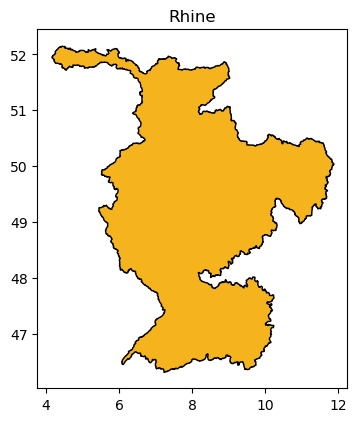

In [2]:
shape = rhine_shape()
catchment = gpd.read_file(shape)

print(shape)
print("bounds (minx, miny, maxx, maxy):", catchment.total_bounds)

catchment.plot(figsize=(4, 5), facecolor="#f5b41d", edgecolor="black")
plt.title("Rhine")
plt.show()

## 3. Lumped forcing

`DestinELumpedMakkinkForcing` gives one time series per variable, averaged over the catchment.
Three keys pick the store:

| key | values |
|---|---|
| `model` | `IFS-NEMO`, `IFS-FESOM`, `ICON` |
| `experiment` | `hist` (1990-2014), `cont`, `SSP3-7.0` (2015-2049) |
| `variant` | `standard` (0.35°, 37 variables), `high-timeseries` and `high-maps` (0.044°, 7 variables) |

Behind `generate()`: the global hourly store is cut to the catchment's bounding box,
clipped to its outline (with `all_touched`, so a catchment smaller than a grid cell
still gets a cell), averaged with cos(latitude) weights, aggregated to daily means, and
Makkink potential evaporation is derived from `tas` and `rsds`. Space is reduced before
time, so only the catchment's hours are ever resampled.

One month over the Rhine takes a minute or so.

In [3]:
lumped = sources["DestinELumpedMakkinkForcing"].generate(
    start_time="2000-06-01T00:00:00Z",
    end_time="2000-06-30T23:00:00Z",
    directory="./forcing/rhine_lumped",
    shape=shape,
    model="IFS-FESOM",
    experiment="hist",
    variant="standard",
)
lumped

ERROR 1: PROJ: internal_proj_create_from_database: /opt/conda/envs/ewatercycle2/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.


DestinELumpedMakkinkForcing(start_time='2000-06-01T00:00:00Z', end_time='2000-06-30T23:00:00Z', directory=PosixPath('/home/mmelotto/ewatercycle-destine/docs/forcing/rhine_lumped'), shape=PosixPath('forcing/rhine_lumped/Rhine.shp'), filenames={'pr': 'DestinE_IFS-FESOM_hist_standard_day_pr_2000-06-01_2000-06-30.nc', 'tas': 'DestinE_IFS-FESOM_hist_standard_day_tas_2000-06-01_2000-06-30.nc', 'rsds': 'DestinE_IFS-FESOM_hist_standard_day_rsds_2000-06-01_2000-06-30.nc', 'evspsblpot': 'DestinE_IFS-FESOM_hist_standard_day_evspsblpot_2000-06-01_2000-06-30.nc'})

## 4. What you get

The variables carry their CMOR names and units: `pr` and `evspsblpot` in kg m-2 s-1,
`tas` in K, `rsds` in W m-2. `filenames` holds basenames rather than paths, which is
what makes the directory movable (section 8).

In [4]:
print(lumped.filenames)
print()
print("absolute path of one variable:", lumped["pr"])

daily = lumped.to_xarray()
daily

{'pr': 'DestinE_IFS-FESOM_hist_standard_day_pr_2000-06-01_2000-06-30.nc', 'tas': 'DestinE_IFS-FESOM_hist_standard_day_tas_2000-06-01_2000-06-30.nc', 'rsds': 'DestinE_IFS-FESOM_hist_standard_day_rsds_2000-06-01_2000-06-30.nc', 'evspsblpot': 'DestinE_IFS-FESOM_hist_standard_day_evspsblpot_2000-06-01_2000-06-30.nc'}

absolute path of one variable: /home/mmelotto/ewatercycle-destine/docs/forcing/rhine_lumped/DestinE_IFS-FESOM_hist_standard_day_pr_2000-06-01_2000-06-30.nc


<xarray.Dataset> Size: 1kB
Dimensions:     (time: 30)
Coordinates:
  * time        (time) datetime64[ns] 240B 2000-06-01 2000-06-02 ... 2000-06-30
    lat         float64 8B 49.21
    lon         float64 8B 8.188
Data variables:
    pr          (time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    tas         (time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    rsds        (time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    evspsblpot  (time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>

The store serves both fluxes as time-mean rates, already in CMOR units, so the plugin
applies no scaling at all. Below they are converted to mm day-1 and °C purely for the
plot.

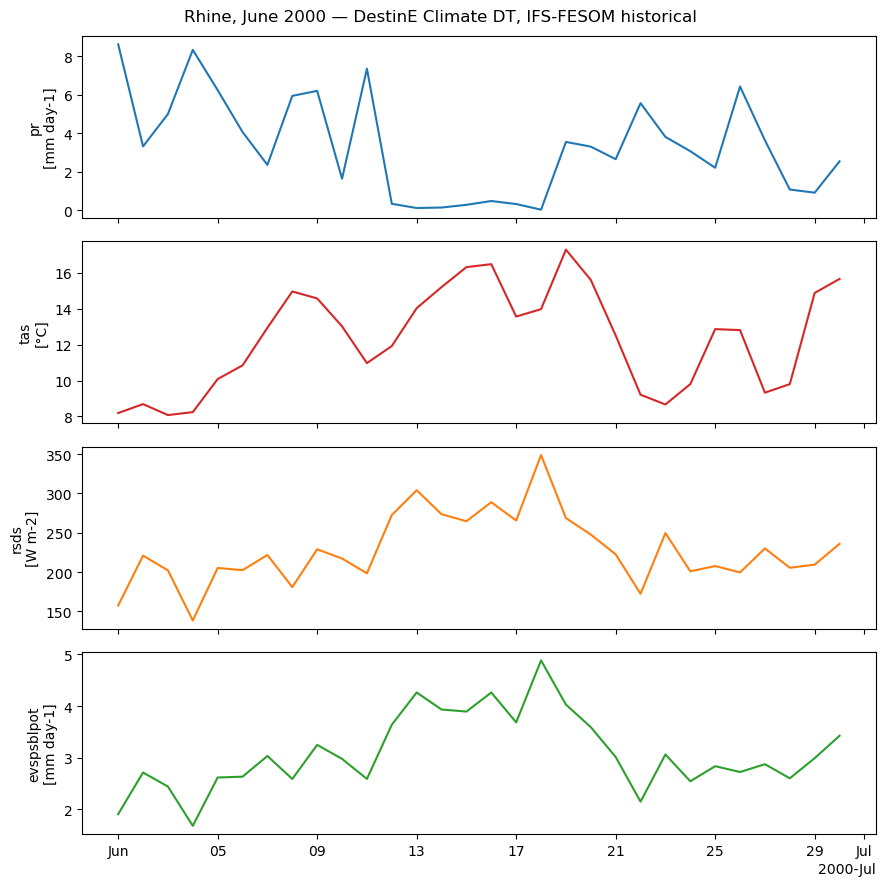

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)

(daily["pr"] * 86400).plot(ax=axes[0], color="#1f77b4")
axes[0].set_ylabel("pr\n[mm day-1]")

(daily["tas"] - 273.15).plot(ax=axes[1], color="#d62728")
axes[1].set_ylabel("tas\n[°C]")

daily["rsds"].plot(ax=axes[2], color="#ff7f0e")
axes[2].set_ylabel("rsds\n[W m-2]")

(daily["evspsblpot"] * 86400).plot(ax=axes[3], color="#2ca02c")
axes[3].set_ylabel("evspsblpot\n[mm day-1]")

for ax in axes:
    ax.set_title("")
    ax.set_xlabel("")

fig.suptitle("Rhine, June 2000 — DestinE Climate DT, IFS-FESOM historical")
fig.tight_layout()
plt.show()

## 5. Distributed forcing

`DestinEForcing` keeps the grid, clipped to the catchment outline. This is where the
high-resolution variants earn their keep: `high-timeseries` is 0.044°, roughly 5 km,
against 0.35° for `standard` — the Rhine comes back as 134×177 cells below, where
`standard` would give roughly 17×22.

It is a `DistributedMakkinkForcing`, the gridded counterpart of the lumped class's
`LumpedMakkinkForcing`, so distributed models accept it directly. The two are
siblings rather than parent and child, so a model that wants a grid cannot be
handed a catchment average by mistake.

`variables` is honoured, so asking for `("pr", "tas")` downloads and writes only those
two.

In [6]:
gridded = sources["DestinEForcing"].generate(
    start_time="2000-06-01T00:00:00Z",
    end_time="2000-06-30T23:00:00Z",
    directory="./forcing/rhine_gridded",
    shape=shape,
    variables=("pr", "tas"),
    model="IFS-FESOM",
    experiment="hist",
    variant="high-timeseries",
)
print(gridded.filenames)

grid = gridded.to_xarray()
print(dict(grid.sizes))

ERROR 1: PROJ: internal_proj_create_from_database: /opt/conda/envs/ewatercycle2/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.


{'pr': 'DestinE_IFS-FESOM_hist_high-timeseries_day_pr_2000-06-01_2000-06-30.nc', 'tas': 'DestinE_IFS-FESOM_hist_high-timeseries_day_tas_2000-06-01_2000-06-30.nc'}
{'time': 30, 'lat': 134, 'lon': 177}


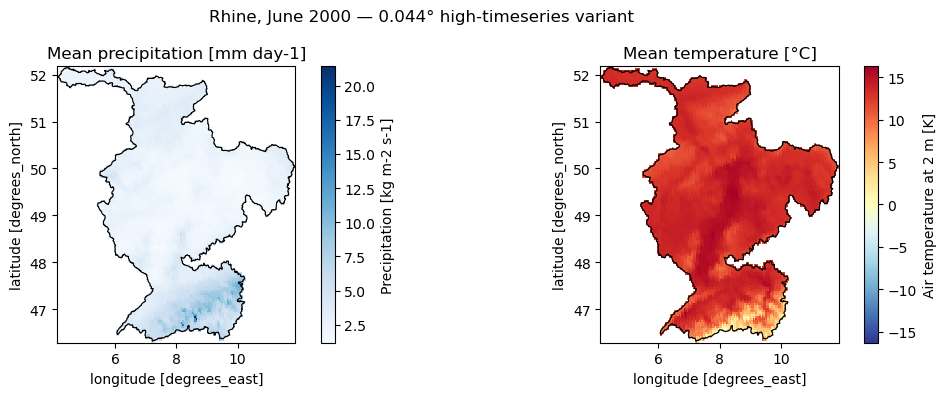

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

(grid["pr"].mean("time") * 86400).plot(ax=left, cmap="Blues")
left.set_title("Mean precipitation [mm day-1]")

(grid["tas"].mean("time") - 273.15).plot(ax=right, cmap="RdYlBu_r")
right.set_title("Mean temperature [°C]")

for ax in (left, right):
    catchment.boundary.plot(ax=ax, color="black", linewidth=0.8)

fig.suptitle("Rhine, June 2000 — 0.044° high-timeseries variant")
fig.tight_layout()
plt.show()

## 6. The variants are not interchangeable

The 0.044° variants carry seven variables, and radiation is not among them. Makkink
potential evaporation is derived from radiation, so `rsds` and `evspsblpot` can only
come from `standard`.

Rather than quietly handing back something coarser, or dropping a variable, the plugin
refuses — before anything is downloaded.

In [8]:
try:
    sources["DestinELumpedMakkinkForcing"].generate(
        start_time="2000-06-01T00:00:00Z",
        end_time="2000-06-30T23:00:00Z",
        directory="./forcing/will_not_be_written",
        shape=shape,
        variables=("pr", "tas", "evspsblpot"),
        variant="high-timeseries",
    )
except ValueError as error:
    print(error)

Variant 'high-timeseries' does not contain ['rsds'], so ['evspsblpot'] cannot be produced from it. Use variant='standard' (0.35 degree), which is the only variant carrying radiation.


## 7. A historical run next to a scenario

The point of a climate digital twin: the same catchment, the same model, decades apart.
`hist` covers 1990-2014, `SSP3-7.0` covers 2015-2049.

Each of these pulls a year of hourly data over the Rhine, so expect them to take
noticeably longer than the one-month calls above.

In [9]:
historical = sources["DestinELumpedMakkinkForcing"].generate(
    start_time="2000-01-01T00:00:00Z",
    end_time="2000-12-31T23:00:00Z",
    directory="./forcing/rhine_2000",
    shape=shape,
    model="IFS-FESOM",
    experiment="hist",
)

scenario = sources["DestinELumpedMakkinkForcing"].generate(
    start_time="2040-01-01T00:00:00Z",
    end_time="2040-12-31T23:00:00Z",
    directory="./forcing/rhine_2040",
    shape=shape,
    model="IFS-FESOM",
    experiment="SSP3-7.0",
)

ERROR 1: PROJ: internal_proj_create_from_database: /opt/conda/envs/ewatercycle2/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_create_from_database: /opt/conda/envs/ewatercycle2/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.


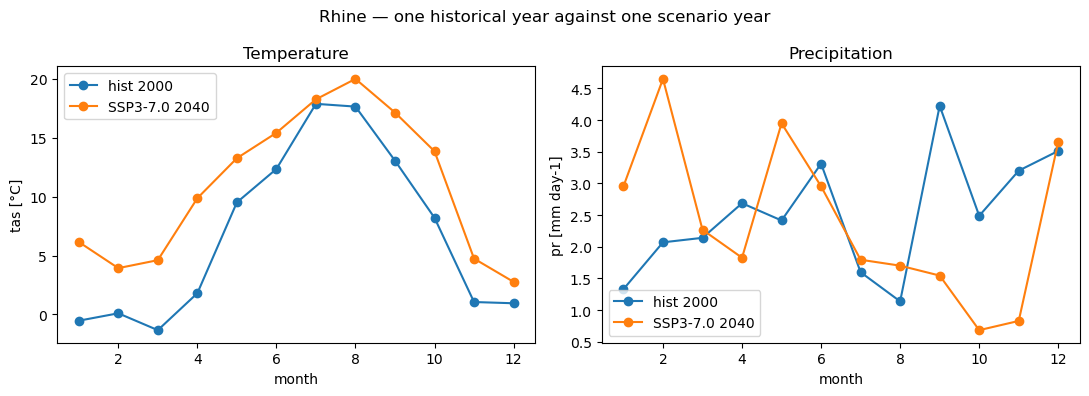

In [10]:
def monthly_mean(forcing, variable):
    """Monthly means of one variable of a forcing object."""
    return forcing.to_xarray()[variable].groupby("time.month").mean()


fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

(monthly_mean(historical, "tas") - 273.15).plot(ax=left, marker="o", label="hist 2000")
(monthly_mean(scenario, "tas") - 273.15).plot(ax=left, marker="o", label="SSP3-7.0 2040")
left.set_ylabel("tas [°C]")
left.set_title("Temperature")
left.legend()

(monthly_mean(historical, "pr") * 86400).plot(ax=right, marker="o", label="hist 2000")
(monthly_mean(scenario, "pr") * 86400).plot(ax=right, marker="o", label="SSP3-7.0 2040")
right.set_ylabel("pr [mm day-1]")
right.set_title("Precipitation")
right.legend()

fig.suptitle("Rhine — one historical year against one scenario year")
fig.tight_layout()
plt.show()

Two single years of one realisation of one model are weather, not a climate signal.
Treat the plot as a demonstration of the plugin rather than as evidence about the Rhine;
for that you would average over many years, and ideally several realisations.

## 8. Saving, moving and reloading

`generate()` has already saved. Next to the NetCDF files sits an
`ewatercycle_forcing.yaml`, and the shapefile has been copied in, so everything is
referenced by name and nothing points outside the directory.

In [11]:
print(Path("./forcing/rhine_lumped/ewatercycle_forcing.yaml").read_text())
print(sorted(path.name for path in Path("./forcing/rhine_lumped").iterdir()))

start_time: '2000-06-01T00:00:00Z'
end_time: '2000-06-30T23:00:00Z'
shape: Rhine.shp
filenames:
  pr: DestinE_IFS-FESOM_hist_standard_day_pr_2000-06-01_2000-06-30.nc
  tas: DestinE_IFS-FESOM_hist_standard_day_tas_2000-06-01_2000-06-30.nc
  rsds: DestinE_IFS-FESOM_hist_standard_day_rsds_2000-06-01_2000-06-30.nc
  evspsblpot: DestinE_IFS-FESOM_hist_standard_day_evspsblpot_2000-06-01_2000-06-30.nc

['DestinE_IFS-FESOM_hist_standard_day_evspsblpot_2000-06-01_2000-06-30.nc', 'DestinE_IFS-FESOM_hist_standard_day_pr_2000-06-01_2000-06-30.nc', 'DestinE_IFS-FESOM_hist_standard_day_rsds_2000-06-01_2000-06-30.nc', 'DestinE_IFS-FESOM_hist_standard_day_tas_2000-06-01_2000-06-30.nc', 'Rhine.dbf', 'Rhine.prj', 'Rhine.shp', 'Rhine.shx', 'ewatercycle_forcing.yaml']


Because of that, the directory can be zipped, copied to a cluster or handed to a
colleague, and still load:

In [12]:
import shutil

shutil.copytree(
    "./forcing/rhine_lumped", "./forcing/rhine_lumped_moved", dirs_exist_ok=True
)

reloaded = sources["DestinELumpedMakkinkForcing"].load("./forcing/rhine_lumped_moved")

print("equal to the original:", reloaded == lumped)
print("resolves its files:   ", reloaded["pr"].is_file())
print("catchment area [m2]:  ", reloaded.get_shape_area())

equal to the original: False
resolves its files:    True
catchment area [m2]:   163645590864.26883


## 9. Feeding it to a model

A forcing object is what an eWaterCycle model takes, so from here it is the usual
workflow: pick a model from `ewatercycle.models.sources`, hand it the forcing, and run
it. `DestinELumpedMakkinkForcing` suits lumped conceptual models, `DestinEForcing` distributed
ones.

## Where to go next

* `scripts/probe_store.py` prints what a store really holds — variables, dimensions,
  latitude order, chunking — which is the quickest way to see what else is among the
  `standard` variant's 37 variables.
* The [Earth Data Hub catalogue](https://earthdatahub.destine.eu/catalogue) lists every
  store in the `climate-dt-2` collection.
* The README covers the API key setup and both classes in condensed form.